# ML Lab 10

## Name - Shreyas Gursale
## Roll No - 23102C0061

 We have used UCI data on wine - https://archive.ics.uci.edu/dataset/109/wine

 This has a lot of features so we apply LDA for dimensionality reduction

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Data Preprocessing and Exploratory Analysis

In [ ]:

cols = ['Wine_Origin','Alcohol','Malic_acid','Ash','Alcalinity_of_ash','Magnesium','Total_phenols',
 	'Flavanoids','Nonflavanoid_phenols','Proanthocyanins','Color_intensity','Hue','OD280/OD315_of_diluted_wines','Proline']

df = pd.read_csv('./data/wine.data',names=cols,index_col=False)

df.head()

,Wine_Origin,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280/OD315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.describe()

,Wine_Origin,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280/OD315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


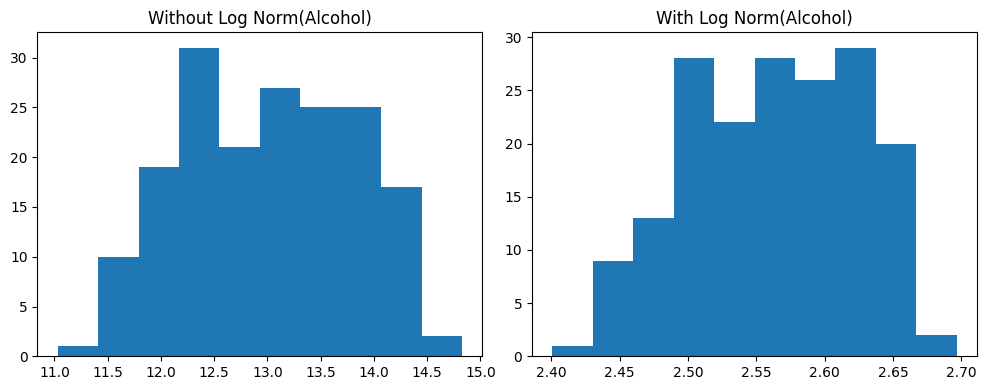

In [ ]:

def show_diff_and_log(df,col_name):
    plt.figure(figsize=(10, 4))


    plt.subplot(1,2,1)
    plt.title(f'Without Log Norm({col_name})')
    plt.hist(df[col_name])

    plt.subplot(1,2,2)
    plt.title(f'With Log Norm({col_name})')
    plt.hist(np.log(df[col_name]))

    plt.tight_layout()
    plt.show()

    df[col_name] = np.log(df[col_name])

show_diff_and_log(df,'Alcohol')

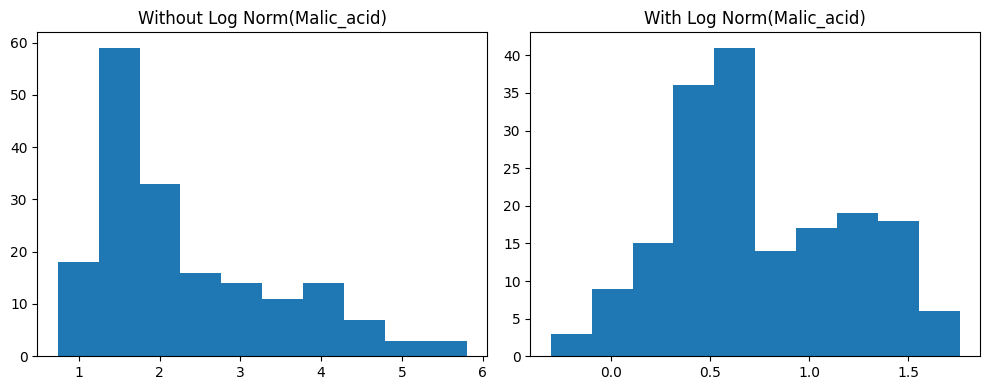

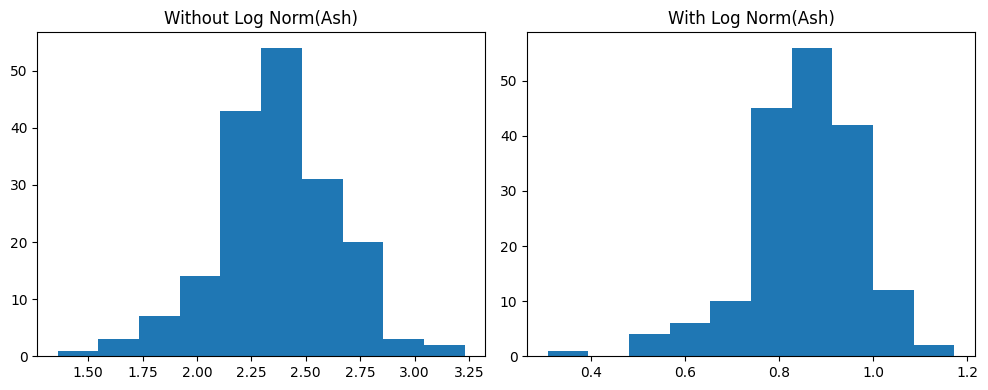

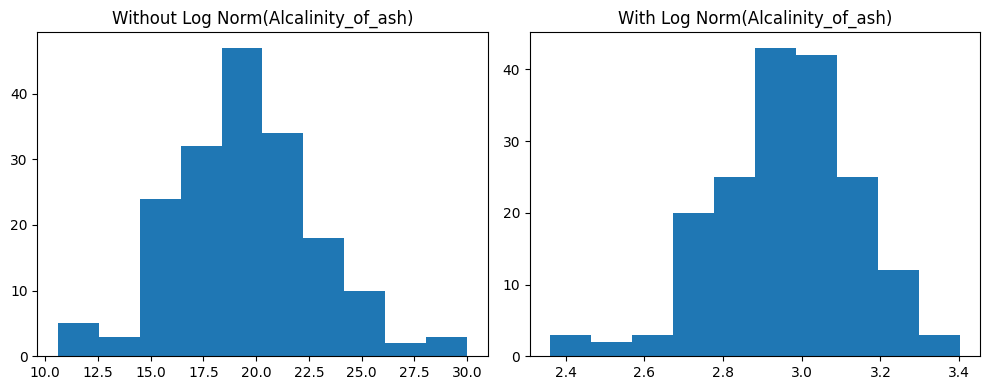

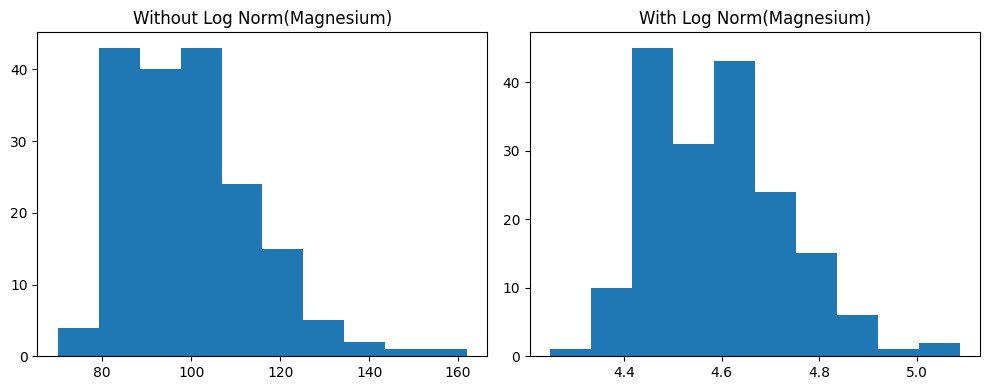

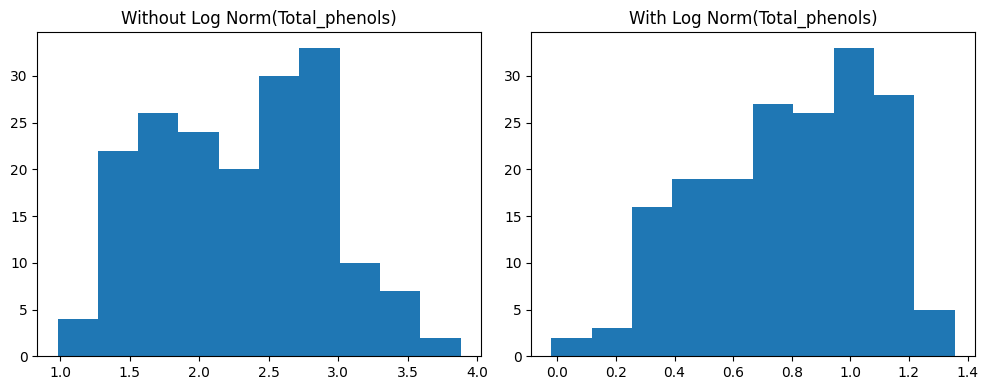

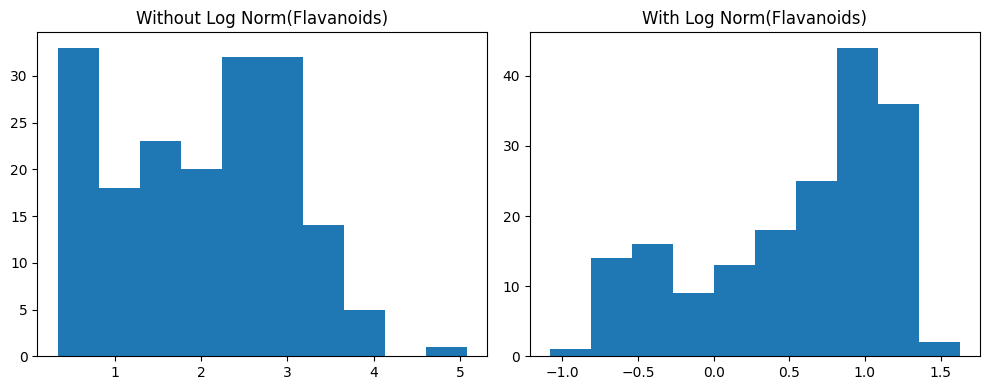

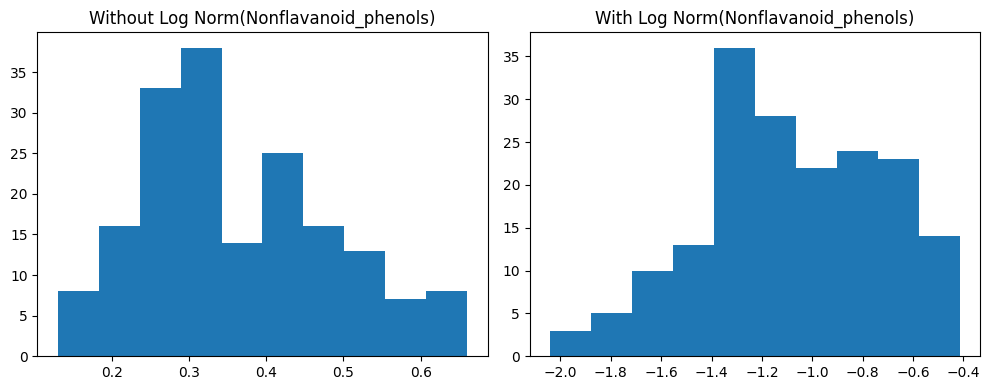

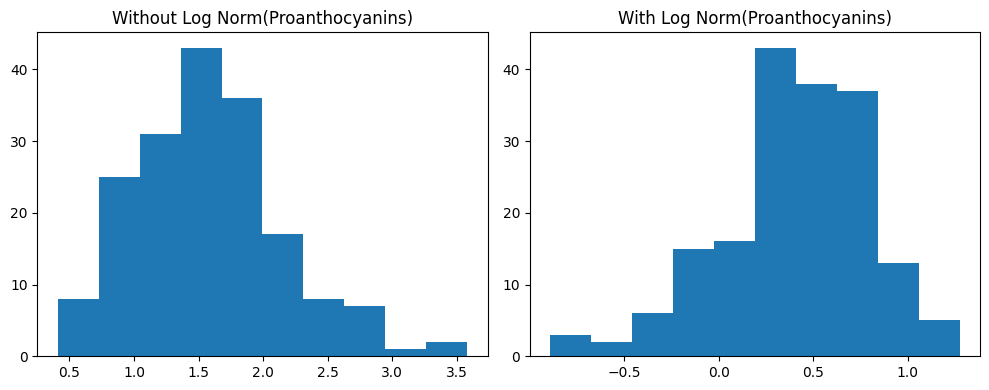

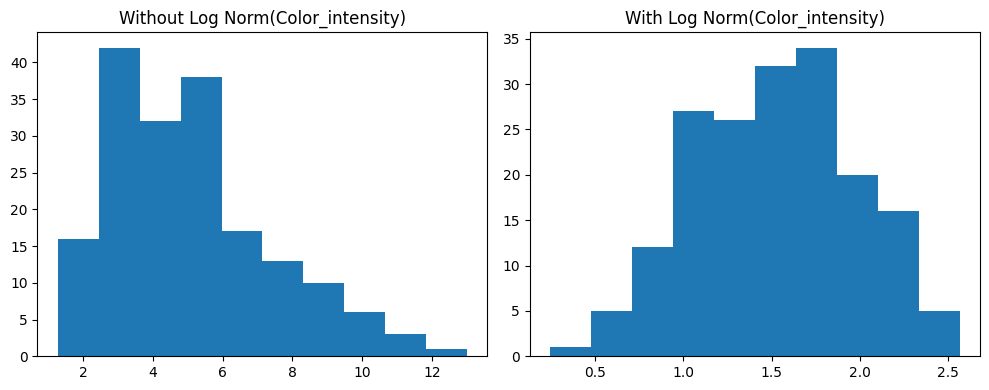

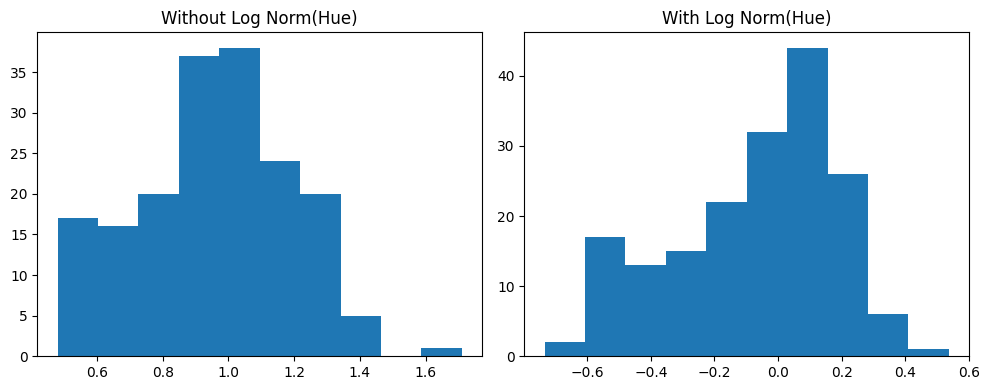

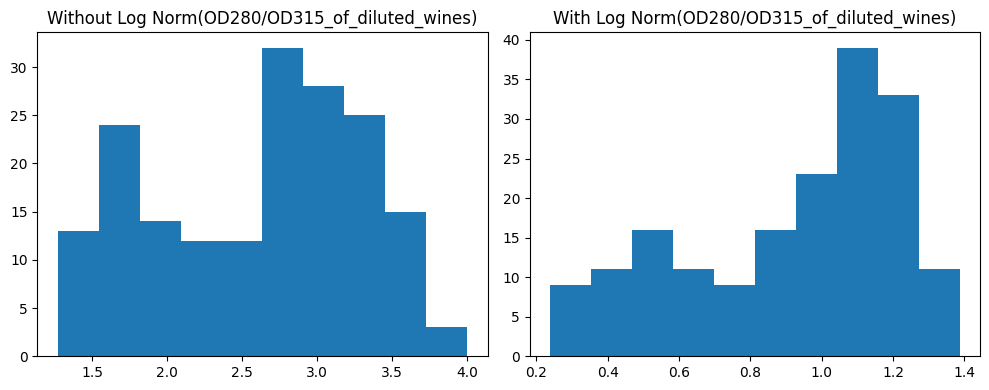

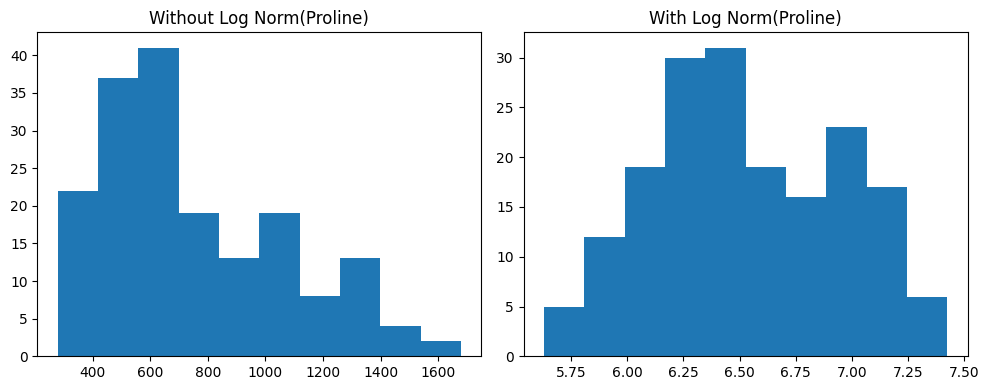

In [ ]:
to_norm = cols.copy()
to_norm.remove('Alcohol')
to_norm.remove('Wine_Origin')
for col in to_norm:
    show_diff_and_log(df,col)

In [ ]:
df.head()

,Wine_Origin,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280/OD315_of_diluted_wines,Proline
0,1,2.655352,0.536493,0.887891,2.747271,4.844187,1.029619,1.118415,-1.272966,0.828552,1.729884,0.039221,1.366092,6.970730
1,1,2.580217,0.576613,0.760806,2.415914,4.605170,0.974560,1.015231,-1.347074,0.246860,1.477049,0.048790,1.223775,6.956545
2,1,2.577182,0.858662,0.982078,2.923162,4.615121,1.029619,1.175573,-1.203973,1.033184,1.736951,0.029559,1.153732,7.077498
3,1,2.665143,0.667829,0.916291,2.821379,4.727388,1.348073,1.249902,-1.427116,0.779325,2.054124,-0.150823,1.238374,7.299797
4,1,2.583243,0.951658,1.054312,3.044522,4.770685,1.029619,0.989541,-0.941609,0.598837,1.463255,0.039221,1.075002,6.599870


# Fitting the LDA model and reducing dimensionality

In [ ]:
y = df['Wine_Origin']
X = df.drop('Wine_Origin',axis=1)

lda = LinearDiscriminantAnalysis(n_components=2)


X_train_orig,X_test,y_train,y_test = train_test_split(X,y,test_size=.25,random_state=42)

scaler = StandardScaler()

X_train_orig = scaler.fit_transform(X_train_orig)
X_test = scaler.transform(X_test)

X_train = lda.fit_transform(X=X_train_orig,y=y_train)
X_test_lda = lda.transform(X=X_test)



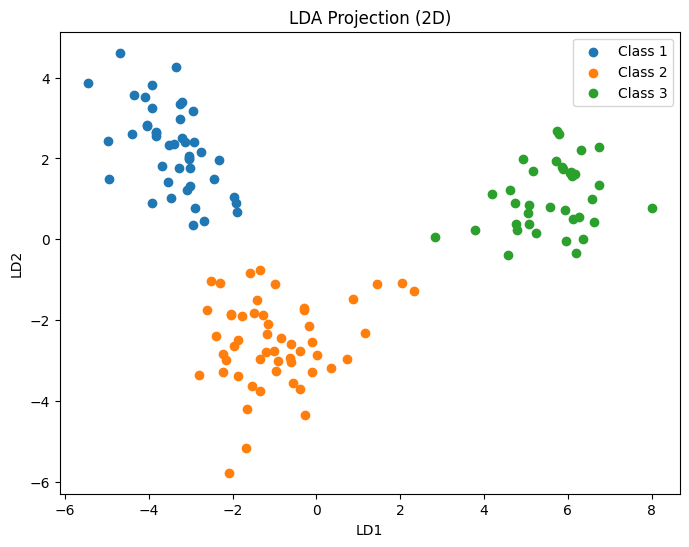

In [ ]:
plt.figure(figsize=(8,6))
for label in np.unique(y_train):
    plt.scatter(
        X_train[y_train == label, 0],
        X_train[y_train == label, 1],
        label=f'Class {label}'
    )

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.title('LDA Projection (2D)')
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=1000,max_depth=10)

rf.fit(X_train,y_train)

y_preds = rf.predict(X_train)


print(accuracy_score(y_train,y_pred=y_preds))

1.0


In [ ]:
y_preds = rf.predict(X_test_lda)

print(accuracy_score(y_test,y_pred=y_preds))

0.9555555555555556


In [ ]:
y_preds = lda.predict(X_test)
print(accuracy_score(y_test,y_preds))

0.9777777777777777
